## Overview

Plot unprocessed data

per variable with overlapping years in one plot, with seasons marked
one variable and the indices marked, which are selected randomly for the validation throu the pipeline module

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 5.6.

In [1]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os
from pathlib import Path

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

import xarray as xr

from my_dataloader_module import TimeseriesDatasetPipeline, TimeseriesPyTorchDataset

rSeed=42

SavePlots = False

## Loading Data

In [4]:
folder="../../../datasets/big_grid"
filename="big_grid-timeseries_sel_vars_2026_march.nc"
!cd {folder} && ls
ds= xr.open_dataset(folder + "/" + filename)
ds

big_grid-timeseries_sel_vars_2023-2025_summer.grib
big_grid-timeseries_sel_vars_2023-2025_summer.nc
big_grid-timeseries_sel_vars_2026_march.grib
big_grid-timeseries_sel_vars_2026_march.nc


<xarray.Dataset> Size: 7MB
Dimensions:  (time: 192, lat: 21, lon: 61)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2026-03-24 ... 2026-03-31T23:00:00
  * lat      (lat) float64 168B 55.0 54.75 54.5 54.25 ... 50.75 50.5 50.25 50.0
  * lon      (lon) float64 488B 0.0 0.25 0.5 0.75 1.0 ... 14.25 14.5 14.75 15.0
Data variables:
    10u      (time, lat, lon) float32 984kB ...
    10v      (time, lat, lon) float32 984kB ...
    2t       (time, lat, lon) float32 984kB ...
    sp       (time, lat, lon) float32 984kB ...
    tp       (time, lat, lon) float32 984kB ...
    str      (time, lat, lon) float32 984kB ...
    tcc      (time, lat, lon) float32 984kB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri May 29 15:58:31 2026: cdo -f nc copy big_grid-timeserie...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [5]:
folder="../../../datasets/small_grid"
image_folder="images"
!cd {folder} && ls

 dataloaders				 grid-timeseries_sel_vars_2017.grib.nc
 grid-timeseries_sel_vars_1950.grib	 grid-timeseries_sel_vars_2018.grib
 grid-timeseries_sel_vars_1950.grib.nc	 grid-timeseries_sel_vars_2018.grib.nc
 grid-timeseries_sel_vars_1960.grib	 grid-timeseries_sel_vars_2019.grib
 grid-timeseries_sel_vars_1960.grib.nc	 grid-timeseries_sel_vars_2019.grib.nc
 grid-timeseries_sel_vars_1970.grib	 grid-timeseries_sel_vars_2020.grib
 grid-timeseries_sel_vars_1970.grib.nc	 grid-timeseries_sel_vars_2020.grib.nc
 grid-timeseries_sel_vars_1980.grib	 grid-timeseries_sel_vars_2021.grib
 grid-timeseries_sel_vars_1980.grib.nc	 grid-timeseries_sel_vars_2021.grib.nc
 grid-timeseries_sel_vars_1990.grib	 grid-timeseries_sel_vars_2022.grib
 grid-timeseries_sel_vars_1990.grib.nc	 grid-timeseries_sel_vars_2022.grib.nc
 grid-timeseries_sel_vars_2000.grib	 grid-timeseries_sel_vars_2023.grib
 grid-timeseries_sel_vars_2000.grib.nc	 grid-timeseries_sel_vars_2023.grib.nc
 grid-timeseries_sel_vars_2010.grib	 grid-tim

In [6]:
#select timeframe
years = [str(year) for year in range(2015,2025)]#recent: range (2015,2025), past:(1950, 2015), test:2025
#years=["2025"]
past="recent_"#"past_"#
#-------------------------------

filelist = [p.name for p in Path(folder).iterdir() if p.is_file()]
#clean filelist, let only .nc files
filelist = [f for f in filelist if f.endswith('.nc')]
filelist.sort()


print(years)
#filter the filelist to only include files for the selected years
filelist = [filename for filename in filelist if any(year in filename for year in years)]
print(filelist)
#filter the filelist to only include files without ssrd in the name
filelist = [filename for filename in filelist if "ssrd" not in filename]
print(filelist)

# Open the NetCDF files using xarray
ds={}
for filename in filelist:
    year = filename.split("_")[3]  # Extract the year from the filename
    ds[year]= xr.open_dataset(folder + "/" + filename)
    ds[year] = xr.decode_cf(ds[year])
    ds[year] = ds[year].assign_coords(time=pd.to_datetime(ds[year].time.values))
ds.keys()
#combining the dict datasets into one xarray dataset
ds_combined = xr.concat([ds[year] for year in ds.keys()], dim='time')
print(ds_combined.data_vars)


print(f"ds_combined.data_vars: {ds_combined.data_vars}" )
    #-------------------------

#splitting into seasons
seasons={"spring": "MAM", "summer": "JJA", "autumn": "SON", "winter": "DJF"}
ds_seasons = {}
for season, code in seasons.items():
    ds_seasons[season] = ds_combined.sel(time=ds_combined['time.season'] == code)

['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
['grid-timeseries_sel_vars_2015.grib.nc', 'grid-timeseries_sel_vars_2016.grib.nc', 'grid-timeseries_sel_vars_2017.grib.nc', 'grid-timeseries_sel_vars_2018.grib.nc', 'grid-timeseries_sel_vars_2019.grib.nc', 'grid-timeseries_sel_vars_2020.grib.nc', 'grid-timeseries_sel_vars_2021.grib.nc', 'grid-timeseries_sel_vars_2022.grib.nc', 'grid-timeseries_sel_vars_2023.grib.nc', 'grid-timeseries_sel_vars_2024.grib.nc']
['grid-timeseries_sel_vars_2015.grib.nc', 'grid-timeseries_sel_vars_2016.grib.nc', 'grid-timeseries_sel_vars_2017.grib.nc', 'grid-timeseries_sel_vars_2018.grib.nc', 'grid-timeseries_sel_vars_2019.grib.nc', 'grid-timeseries_sel_vars_2020.grib.nc', 'grid-timeseries_sel_vars_2021.grib.nc', 'grid-timeseries_sel_vars_2022.grib.nc', 'grid-timeseries_sel_vars_2023.grib.nc', 'grid-timeseries_sel_vars_2024.grib.nc']
Data variables:
    10u      (time, lat, lon) float32 9MB 7.11 6.43 5.352 ... 9.848 10.36 10.14
 

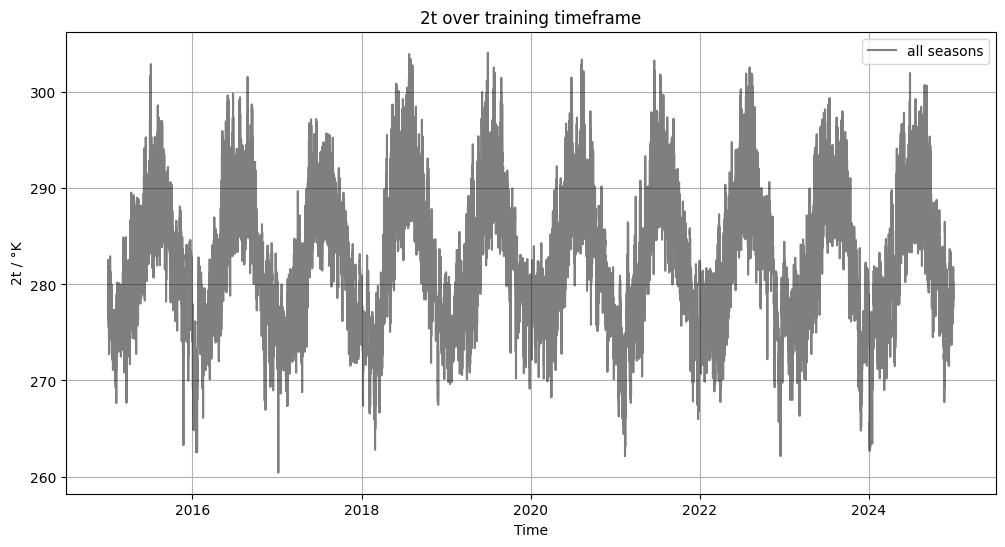

In [7]:

#plot per variable with overlapping years in one plot, with seasons marked
#selecting only one location for plotting, e.g. lat=0, lon=0
ds_plot_point = ds_combined.sel(lat=55.75, lon=12.5, method='nearest')

var = list(ds_combined.data_vars.keys())[2] #select the first variable for plotting, e.g. "t2m"
fig,ax = plt.subplots(figsize=(12, 6))
ax.plot(ds_plot_point.time, ds_plot_point[var], label="all seasons", color="black", alpha=0.5)
ax.set_title(f"{var} over training timeframe")
ax.set_xlabel("Time")
ax.set_ylabel(f"{var} / °K")
ax.legend()
ax.grid()
if SavePlots:
    fig.savefig(f"{image_folder}/{var}_over_training_timeframe.png")
    

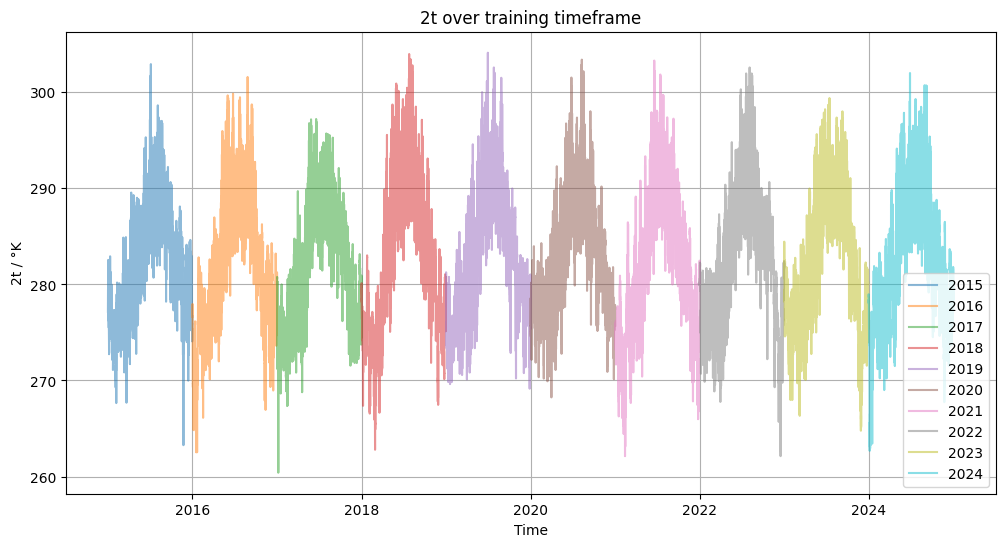

In [8]:
#plotting all the data overlaying the years, with one line per year, to see the seasonal patterns and trends over the years


var = list(ds_combined.data_vars.keys())[2] #select the first variable for plotting, e.g. "t2m"
fig,ax = plt.subplots(figsize=(12, 6))
#selecting only one year for plotting, e.g. 2015 from ds_combined
for y in years:
    ds_plot_yearly = ds_plot_point.sel(time=ds_plot_point['time.year'] == int(y))
    ax.plot(ds_plot_yearly.time, ds_plot_yearly[var], label=f"{y}", alpha=0.5)
    
ax.set_title(f"{var} over training timeframe")
ax.set_xlabel("Time")
ax.set_ylabel(f"{var} / °K")
ax.legend()
ax.grid()
if SavePlots:
    fig.savefig(f"{image_folder}/{var}_over_training_timeframe_colored.png")

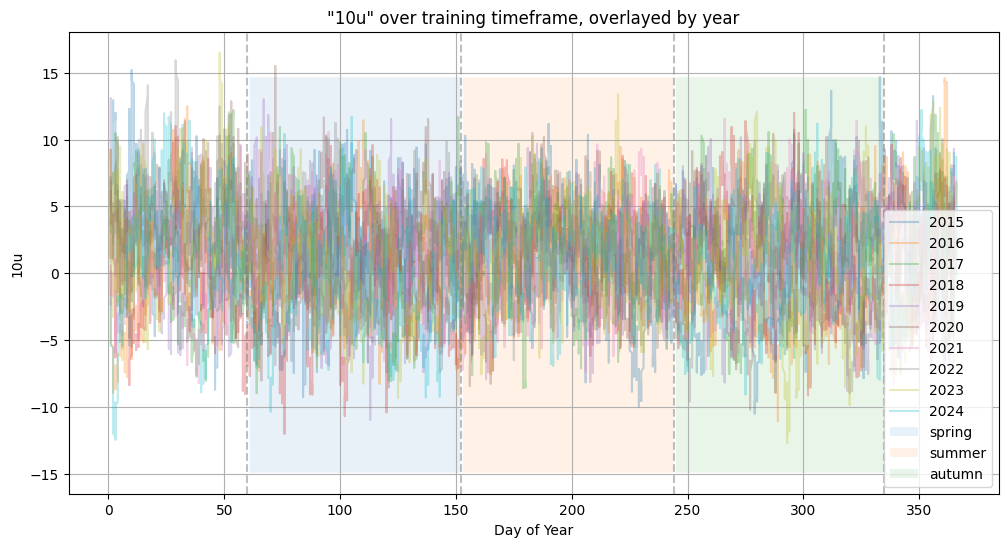

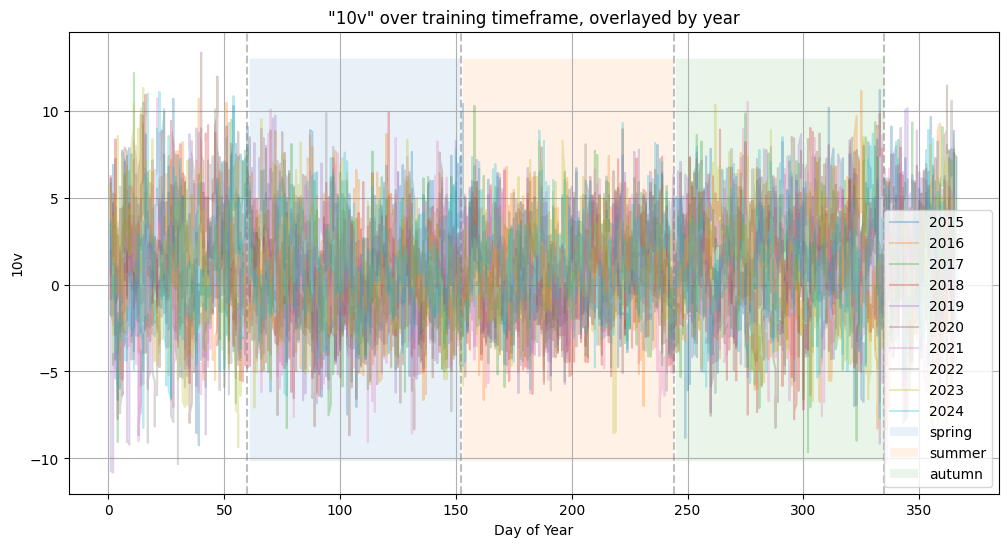

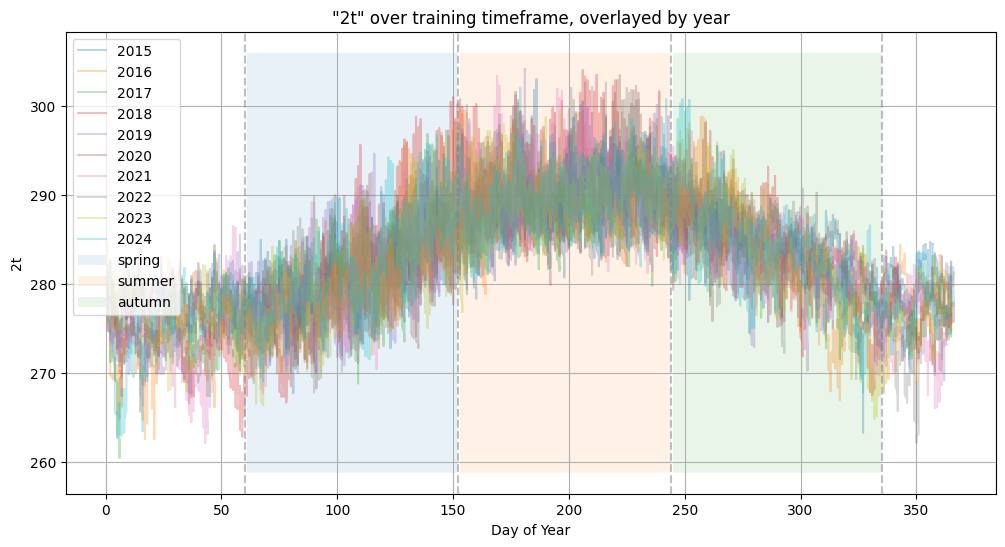

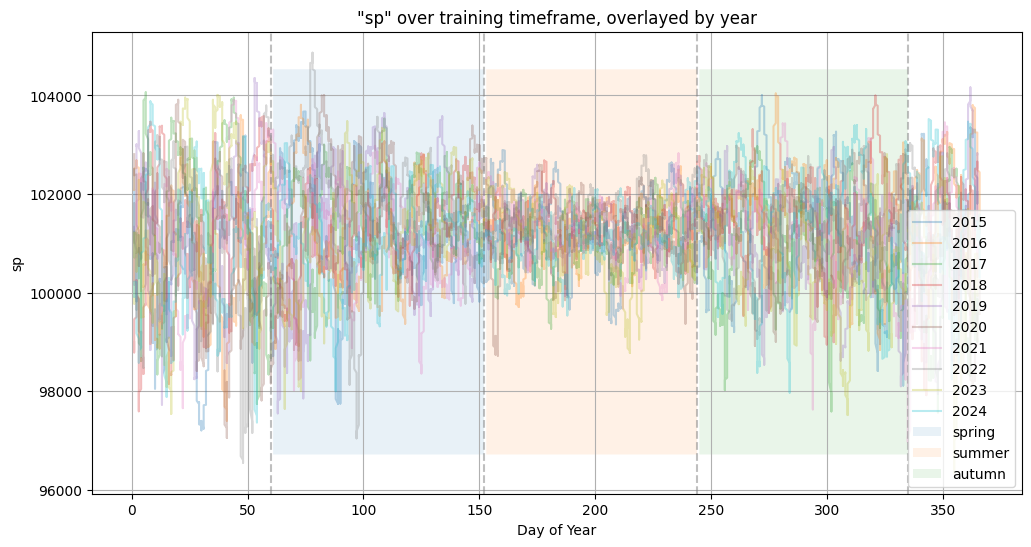

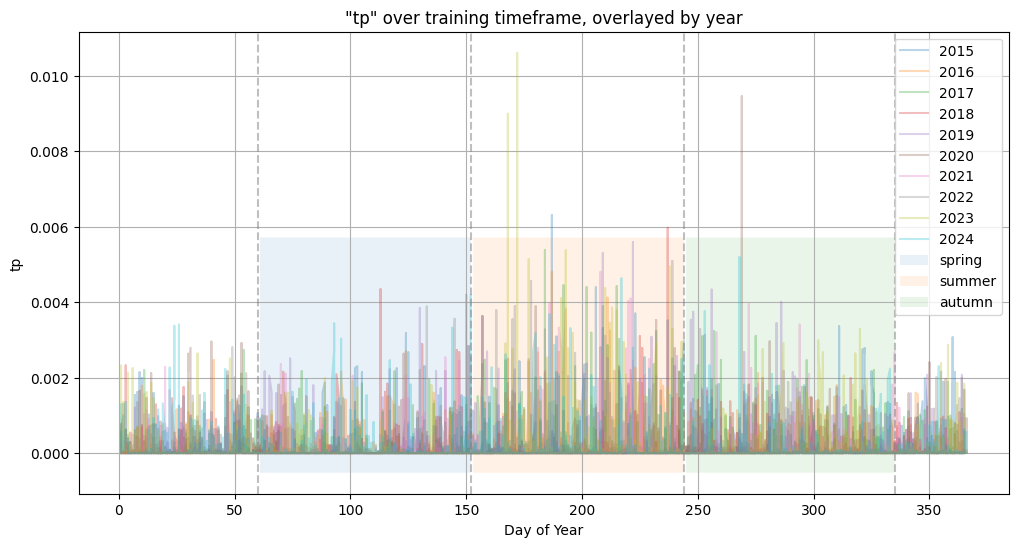

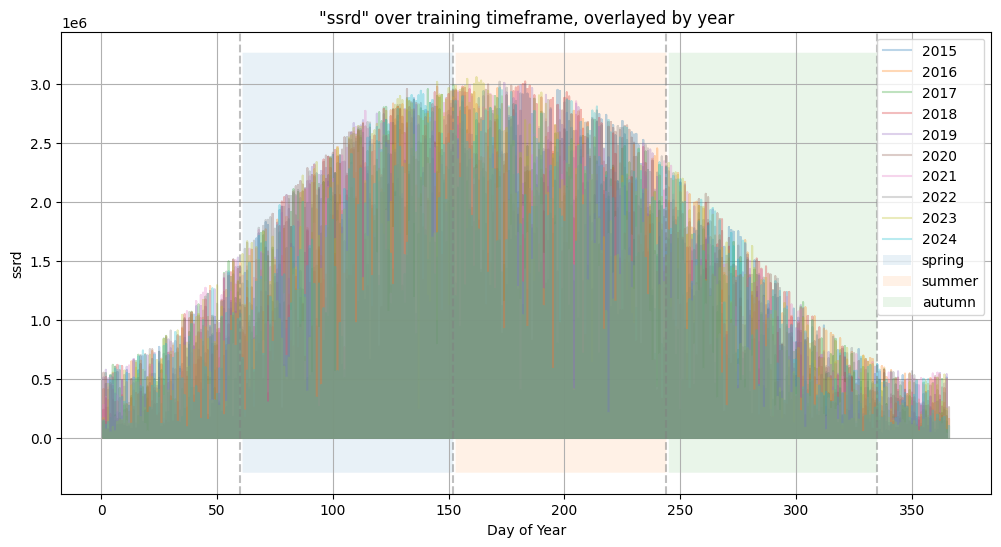

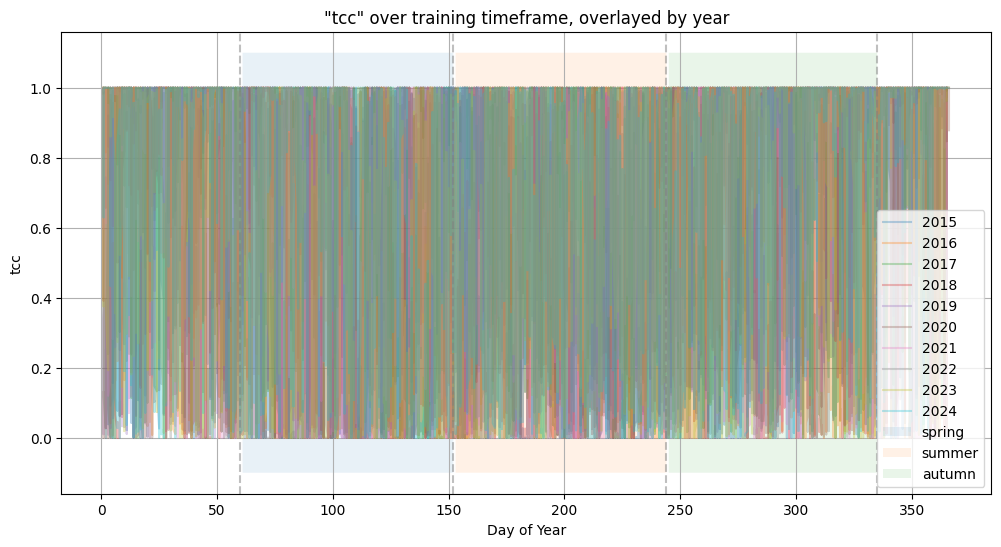

In [36]:
#plotting the years overlayed, so that for every year, it begins at the same time, to see the seasonal patterns more clearly
for var in ds_combined.data_vars.keys():
    fig, ax = plt.subplots(figsize=(12, 6))
    for y in years:
        ds_year = ds_plot_point.sel(time=ds_plot_point['time.year'] == int(y))
        #recalculate as degrees Celsius
        # convert to °C as a numpy 1D array
        val = ds_year[var].data.astype(np.float32)# - 273.15
        ax.plot(ds_year.time.dt.dayofyear, val, label=y,alpha=0.3)

    #plot seasons as areas of underlayed color with the season code from seasons dict
    min,max=val.min(), val.max()
    diff = max - min
    min -= diff*0.1
    max += diff*0.1
    
    ds_seasons_point = ds_seasons.copy()
    for season, code in seasons.items():
        if season == "winter":
            ax.axvline(ds_seasons_point["autumn"].time.dt.dayofyear.max(), color="grey", linestyle="--", alpha=0.5)
            continue
        ax.axvline(ds_seasons_point[season].time.dt.dayofyear.min(), color="grey", linestyle="--", alpha=0.5)
        ds_seasons_point[season] = ds_year.sel(time=ds_year['time.season'] == code)
        ax.fill_between(ds_seasons_point[season].time.dt.dayofyear, min, max, alpha=0.1, label=season)
    ax.set_title(f'"{var}" over training timeframe, overlayed by year')
    ax.set_xlabel("Day of Year")
    ax.set_ylabel(f'{var}')
    ax.legend()
    ax.grid()
    if SavePlots:
        fig.savefig(f"{image_folder}/{var}_over_training_timeframe_overlayed_by_year.png")

In [10]:
for var in ds_combined.data_vars.keys():
    print(var)

10u
10v
2t
sp
tp
ssrd
tcc


In [33]:
ds_year = ds_plot_point.sel(time=ds_plot_point['time.year'] == int(2021))
#recalculate as degrees Celsius
# convert to °C as a numpy 1D array
val = ds_year[var].data.astype(np.float32)# - 273.15
val[:10]
years
timeframe=ds_year.time.dt.dayofyear
timeframe

<xarray.DataArray 'dayofyear' (time: 8760)> Size: 70kB
array([  1,   1,   1, ..., 365, 365, 365], shape=(8760,))
Coordinates:
  * time     (time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-31T23:00:00
    lon      float64 8B 12.5
    lat      float64 8B 55.75

val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8784,)
val_array shape: (10, 8760)
val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8784,)
val_array shape: (10, 8760)
val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8760,)
val_array shape: (10, 8760)
val shape: (8784,)
val_array shape: (10, 8760)
<xarray.DataArray 'dayofyear' (time: 8784)> Size: 70kB
array([  1,   1,   1, ..., 366, 366, 366], shape=(8784,))
Coordinates:
  * time     (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
    lon      float64 8B 12.5
    lat      float64 8B 55.75


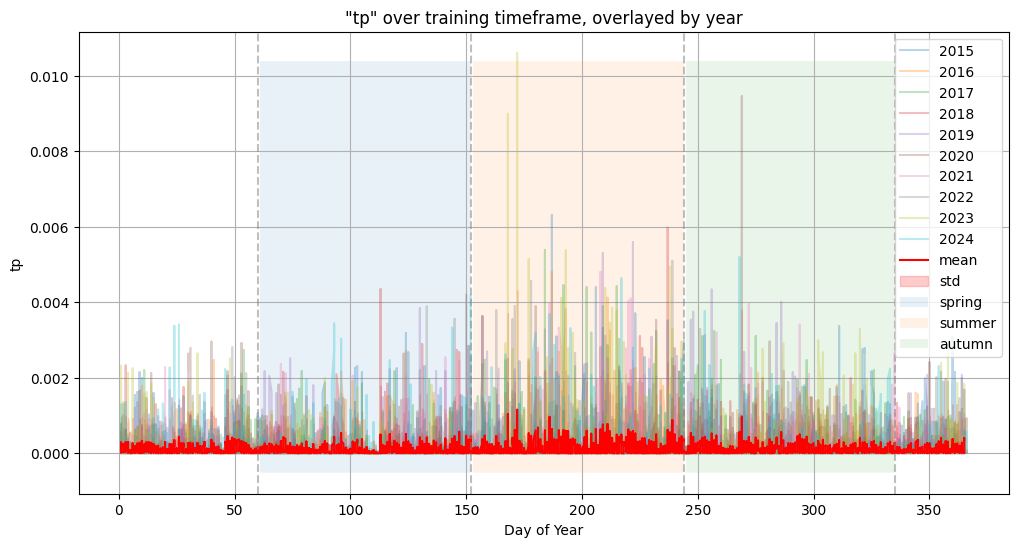

In [40]:
#plotting the years overlayed, so that for every year, it begins at the same time, to see the seasonal patterns more clearly
var="tp"
val_array = np.zeros((len(years), 8760)) #initialize an array to store the values for each year, with 8760 hours in a year
fig, ax = plt.subplots(figsize=(12, 6))
for y in years:
    ds_year = ds_plot_point.sel(time=ds_plot_point['time.year'] == int(y))
    #recalculate as degrees Celsius
    # convert to °C as a numpy 1D array
    val = ds_year[var].data.astype(np.float32)# - 273.15
    print(f"val shape: {val.shape}")
    val_array[(int(y) - int(years[0])), :] = val[:8760]
    print(f"val_array shape: {val_array.shape}")
    ax.plot(ds_year.time.dt.dayofyear, val, label=y,alpha=0.3)

print(ds_year.time.dt.dayofyear)

mean_val = np.mean(val_array, axis=0)
ax.plot(timeframe,mean_val, label="mean", color="red")#, linewidth=2)
std_val = np.std(val_array, axis=0)
ax.fill_between(timeframe, mean_val, mean_val + std_val, color="red", alpha=0.2, label="std")

#plot seasons as areas of underlayed color with the season code from seasons dict
min,max=val.min(), val.max()
diff = max - min
min -= diff*0.1
max += diff*1

ds_seasons_point = ds_seasons.copy()
for season, code in seasons.items():
    if season == "winter":
        ax.axvline(ds_seasons_point["autumn"].time.dt.dayofyear.max(), color="grey", linestyle="--", alpha=0.5)
        continue
    ax.axvline(ds_seasons_point[season].time.dt.dayofyear.min(), color="grey", linestyle="--", alpha=0.5)
    ds_seasons_point[season] = ds_year.sel(time=ds_year['time.season'] == code)
    ax.fill_between(ds_seasons_point[season].time.dt.dayofyear, min, max, alpha=0.1, label=season)
ax.set_title(f'"{var}" over training timeframe, overlayed by year')
ax.set_xlabel("Day of Year")
ax.set_ylabel(f'{var}')
ax.legend()
ax.grid()
if True:
    fig.savefig(f"{image_folder}/{var}_over_training_timeframe_overlayed_by_year.png")

In [19]:
#calculating random indices for training and testing
batch_size=64
lag_selection=[0, 24, 48, 60, 66, 69, 71]
validate_ratio=0.20
target_var=4

pipeline = TimeseriesDatasetPipeline(ds_combined, lag_selection,1,target_var)
train_indices, test_indices = pipeline.create_random_train_test_split_idx(test_size=0.2,random_state=rSeed)
print(f"Train indices: {train_indices}")
print(f"Test indices: {test_indices}")

Data prepared with shape: (87672, 7, 5, 5)
Train indices: [59845 38347 11421 ... 76820   860 15795]
Test indices: [ 9983 43268 16408 ... 53240 55784 20657]


In [37]:
ds_seasons

{'spring': <xarray.Dataset> Size: 16MB
 Dimensions:  (time: 22080, lat: 5, lon: 5)
 Coordinates:
   * time     (time) datetime64[ns] 177kB 2015-03-01 ... 2024-05-31T23:00:00
   * lat      (lat) float64 40B 56.0 55.75 55.5 55.25 55.0
   * lon      (lon) float64 40B 12.0 12.25 12.5 12.75 13.0
 Data variables:
     10u      (time, lat, lon) float32 2MB -0.4971 -0.586 ... -5.121 -5.389
     10v      (time, lat, lon) float32 2MB 8.878 8.253 7.158 ... -3.649 -3.673
     2t       (time, lat, lon) float32 2MB 275.7 275.3 274.8 ... 287.5 287.6
     sp       (time, lat, lon) float32 2MB 1.005e+05 1.005e+05 ... 1.012e+05
     tp       (time, lat, lon) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
     ssrd     (time, lat, lon) float32 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
     tcc      (time, lat, lon) float32 2MB 1.0 1.0 1.0 ... 0.3754 0.2581 0.1952
 Attributes:
     CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
     Conventions:  CF-1.6
     institution:  Euro

In [139]:
used_indices={}
i=0
for season,ds_s in ds_seasons.items():
    i=i+1
    print(f"Season: {season}")
    #print(ds_s.)
    
    pipeline = TimeseriesDatasetPipeline(ds_s, lag_selection,1,target_var)
    train_indices, test_indices = pipeline.create_random_train_test_split_idx(test_size=0.2,random_state=i)
    
    train_indices=np.array(train_indices)
    test_indices=np.array(test_indices)
    used_indices[season] = np.concatenate((train_indices, test_indices))
    used_indices[season].sort()
    train_indices.sort()
    test_indices.sort()
    print(f"Train indices: {train_indices}")
    print(f"Test indices: {test_indices}")
    print(f"Used indices for season {season}: {used_indices[season]}")




Season: spring
Data prepared with shape: (22080, 7, 5, 5)
Train indices: [    1     2     3 ... 22005 22006 22007]
Test indices: [    0     4     6 ... 21998 22000 22001]
Used indices for season spring: [    0     1     2 ... 22005 22006 22007]
Season: summer
Data prepared with shape: (22080, 7, 5, 5)
Train indices: [    0     1     2 ... 22005 22006 22007]
Test indices: [    4     8    10 ... 21988 21991 21999]
Used indices for season summer: [    0     1     2 ... 22005 22006 22007]
Season: autumn
Data prepared with shape: (21840, 7, 5, 5)
Train indices: [    0     1     2 ... 21765 21766 21767]
Test indices: [   14    19    23 ... 21753 21761 21762]
Used indices for season autumn: [    0     1     2 ... 21765 21766 21767]
Season: winter
Data prepared with shape: (21672, 7, 5, 5)
Train indices: [    1     2     3 ... 21595 21598 21599]
Test indices: [    0     8    12 ... 21589 21596 21597]
Used indices for season winter: [    0     1     2 ... 21597 21598 21599]


In [128]:
used_indices["summer"]

In [108]:
def conv_timestamp_to_dayofyear(timestamp):
    return pd.to_datetime(timestamp).dayofyear.values-1

def conv_timestamp_to_idx(timestamp):
    #expressed as index of number of hours since the beginning of the year
    hour_of_year = pd.to_datetime(timestamp).hour + conv_timestamp_to_dayofyear(timestamp) * 24
    return hour_of_year.values

def conv_rel_idx_to_abs_idx(rel_idx, season):
    #convert relative index to absolute index in the combined dataset, based on the season
    season_start_idx = (conv_timestamp_to_idx(ds_seasons_point[season].time)).min()
    return season_start_idx + rel_idx


In [111]:
(conv_timestamp_to_idx(ds_seasons_point["autumn"].time)).min()

np.int32(5856)

In [112]:
conv_rel_idx_to_abs_idx(train_indices, "autumn")

array([ 5856,  5857,  5858, ..., 27452, 27453, 27455], shape=(17280,))

In [117]:
def conv_idx_to_timestamp(abs_idx,year=2020):
    #convert index of number of hours since the beginning of the year to timestamp
    dayofyear = abs_idx // 24
    hour = abs_idx % 24
    timestamp = pd.to_datetime(f"{year}-01-01") + pd.Timedelta(days=dayofyear) + pd.Timedelta(hours=hour)
    return timestamp

def count_idx_per_day(abs_idx_list):
    #count how many indices correspond to each day of the year, given that there are 24 indices per day
    dayofyear = abs_idx_list // 24
    return np.array([np.sum(dayofyear == i) for i in range(1, 367)])

def give_array_of_indices_for_year(year=2020):
    #given a year, return a list of indices that correspond to that year, based on the fact that there are 24 indices per day and 365 days in a year
    if year % 4 == 0:
        #leap year
        return np.array(range(0, 366*24))
    return np.array(range(0, 365*24))


In [119]:
train_indices
#conv_idx_to_timestamp(train_indices[10000])

#give_array_of_indices_for_year(2020)

array([    0,     1,     2, ..., 21596, 21597, 21599], shape=(17280,))

In [100]:
#print(ds_plot_point.time)

#print(conv_timestamp_to_dayofyear(ds_plot_point.time))
#print(conv_timestamp_to_idx(ds_plot_point.time))
#print(conv_rel_idx_to_abs_idx(train_indices, "autumn"))

#ts=ds_seasons_point["autumn"].time#.min()
#print(ts)
#print(conv_timestamp_to_dayofyear(ts))

#print(conv_timestamp_to_idx(ts))
#pd.to_datetime(ts)
#ts.to_index()

Used indices for season spring: [ 1440  1441  1442 ... 23445 23446 23447]
Used indices for season summer: [ 3648  3649  3650 ... 25653 25654 25655]
Used indices for season autumn: [ 5856  5857  5858 ... 27621 27622 27623]
Used indices for season winter: [    0     1     2 ... 21597 21598 21599]
[]
[ 3648  3649  3650 ... 25653 25654 25655]


[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24
 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24 24

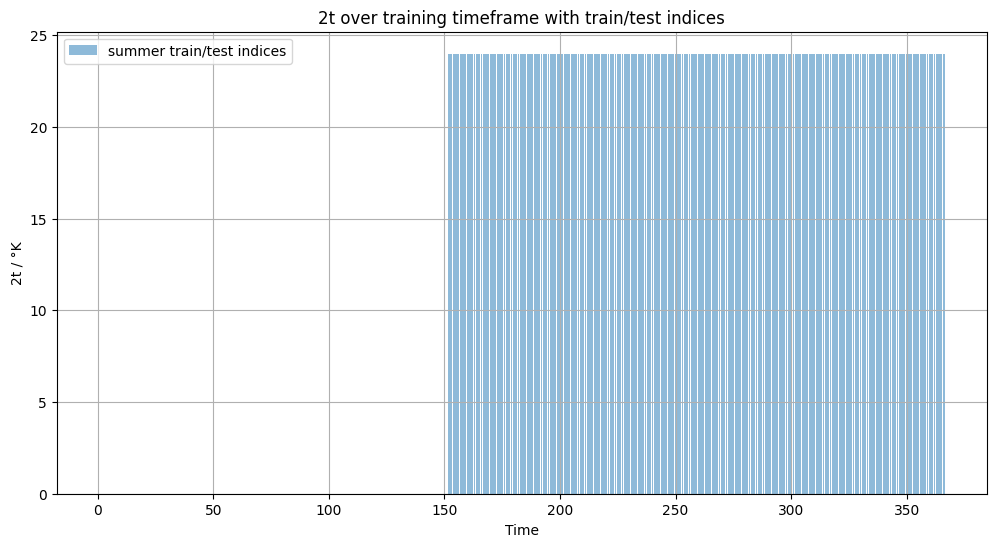

In [145]:
#plotting the train and test indices on the same plot as the variable over time, to see how they are distributed
var="2t"
year=2020
min_time = pd.to_datetime(f"{year}-01-01")
max_time = pd.to_datetime(f"{year}-12-31")

fig, ax = plt.subplots(figsize=(12, 6))

total_idx_list = give_array_of_indices_for_year(year)
used_indices_season_abs={}
for season, ds_s in ds_seasons.items():
    i=0
    #plotting vlines for season boundaries
    #plot train and test inidces per season as histogram of the day of year, with different colors for train and test
    used_indices_season_rel = used_indices[season]
    u=conv_rel_idx_to_abs_idx(used_indices_season_rel, season)
    used_indices_season_abs[season] = u
    print(f"Used indices for season {season}: {u}")

total_used_indices_season_abs = np.concatenate(list(used_indices_season_abs.values()))
not_used_indices_season_abs = np.setdiff1d(total_idx_list, total_used_indices_season_abs)
print(not_used_indices_season_abs)
#counts = count_idx_per_day(used_indices_season_abs)
#ax.bar(range(1, 367), counts, alpha=0.5, label=f"{season} train/test indices")
print(used_indices_season_abs["summer"])
counts_used = count_idx_per_day(used_indices_season_abs["summer"])
print(counts_used)
ax.bar(range(1, 367), counts_used, alpha=0.5, label=f"summer train/test indices")
#set xlim to the timeframe of 2020 to 2021

#ax.set_xlim(min_time, max_time)
ax.set_title(f"{var} over training timeframe with train/test indices")
ax.set_xlabel("Time")
ax.set_ylabel(f"{var} / °K")
ax.legend()
ax.grid()
if SavePlots:
    fig.savefig(f"images/{var}_over_training_timeframe_with_train_test_indices.png")

In [9]:
min=ds_plot.time.min()
max=ds_plot.time.max()
diff = max - min    
length = int(len(ds_plot.time))
print(f"min: {min}")
print(f"max: {max}")
print(f"diff: {diff}")
print(f"length: {length}")



min: <xarray.DataArray 'time' ()> Size: 8B
array('2015-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    lon      float64 8B 12.5
    lat      float64 8B 55.75
max: <xarray.DataArray 'time' ()> Size: 8B
array('2024-12-31T23:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    lon      float64 8B 12.5
    lat      float64 8B 55.75
diff: <xarray.DataArray 'time' ()> Size: 8B
array(315615600000000000, dtype='timedelta64[ns]')
Coordinates:
    lon      float64 8B 12.5
    lat      float64 8B 55.75
length: 87672


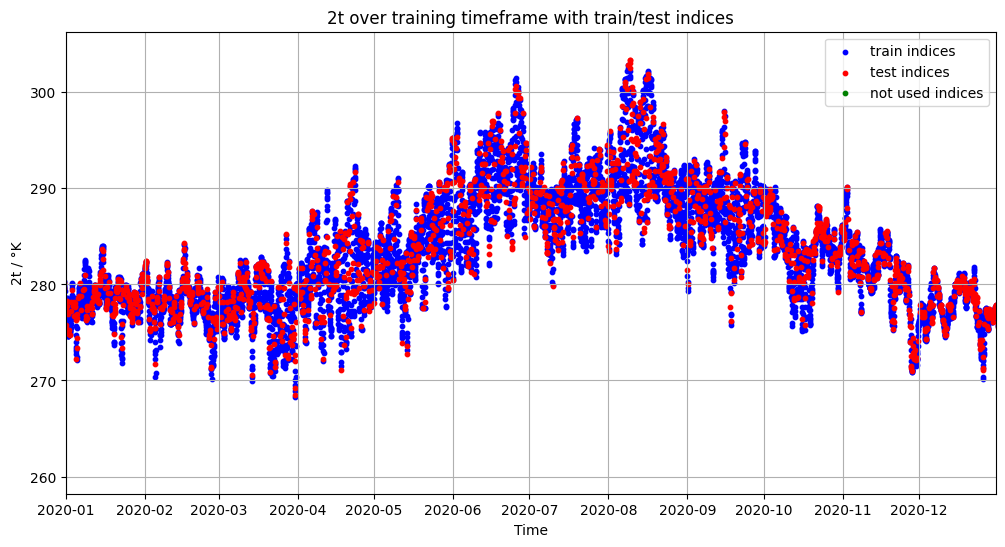

In [89]:
#plotting the indices, which were not used for training and validation, to see how they are distributed over the seasons
var="2t"
fig, ax = plt.subplots(figsize=(12, 6))
#plotting vlines for season boundaries
ax.axvline(ds_seasons["spring"].time.dt.dayofyear.min(), color="grey", linestyle="--", alpha=0.5)
ax.axvline(ds_seasons["summer"].time.dt.dayofyear.min(), color="grey", linestyle="--", alpha=0.5)
ax.axvline(ds_seasons["autumn"].time.dt.dayofyear.min(), color="grey", linestyle="--", alpha=0.5)
ax.axvline(ds_seasons["autumn"].time.dt.dayofyear.max(), color="grey", linestyle="--", alpha=0.5)

#set xlim to the timeframe of 2020 to 2021
min_time = pd.to_datetime("2020-01-01")
max_time = pd.to_datetime("2020-12-31")


ax.scatter(ds_plot.time[train_indices], ds_plot[var][train_indices], label="train indices", color="blue", s=10)
ax.scatter(ds_plot.time[test_indices], ds_plot[var][test_indices], label="test indices", color="red", s=10)
ax.scatter(ds_plot.time[not_used_indices], ds_plot[var][not_used_indices], label="not used indices", color="green", s=10)

ax.set_xlim(min_time, max_time)
ax.set_title(f"{var} over training timeframe with train/test indices")
ax.set_xlabel("Time")
ax.set_ylabel(f"{var} / °K")
ax.legend()
ax.grid()

In [47]:

not_used_indices = [i for i in range(len(ds_plot.time)) if i not in train_indices and i not in test_indices]
not_used_times=not_used_indices #= ds_plot.time[not_used_indices]
print(f"Not used times: {not_used_times}")

Not used times: [87600, 87601, 87602, 87603, 87604, 87605, 87606, 87607, 87608, 87609, 87610, 87611, 87612, 87613, 87614, 87615, 87616, 87617, 87618, 87619, 87620, 87621, 87622, 87623, 87624, 87625, 87626, 87627, 87628, 87629, 87630, 87631, 87632, 87633, 87634, 87635, 87636, 87637, 87638, 87639, 87640, 87641, 87642, 87643, 87644, 87645, 87646, 87647, 87648, 87649, 87650, 87651, 87652, 87653, 87654, 87655, 87656, 87657, 87658, 87659, 87660, 87661, 87662, 87663, 87664, 87665, 87666, 87667, 87668, 87669, 87670, 87671]


In [48]:
ds_plot.time[not_used_indices]

<xarray.DataArray 'time' (time: 72)> Size: 576B
array(['2024-12-29T00:00:00.000000000', '2024-12-29T01:00:00.000000000',
       '2024-12-29T02:00:00.000000000', '2024-12-29T03:00:00.000000000',
       '2024-12-29T04:00:00.000000000', '2024-12-29T05:00:00.000000000',
       '2024-12-29T06:00:00.000000000', '2024-12-29T07:00:00.000000000',
       '2024-12-29T08:00:00.000000000', '2024-12-29T09:00:00.000000000',
       '2024-12-29T10:00:00.000000000', '2024-12-29T11:00:00.000000000',
       '2024-12-29T12:00:00.000000000', '2024-12-29T13:00:00.000000000',
       '2024-12-29T14:00:00.000000000', '2024-12-29T15:00:00.000000000',
       '2024-12-29T16:00:00.000000000', '2024-12-29T17:00:00.000000000',
       '2024-12-29T18:00:00.000000000', '2024-12-29T19:00:00.000000000',
       '2024-12-29T20:00:00.000000000', '2024-12-29T21:00:00.000000000',
       '2024-12-29T22:00:00.000000000', '2024-12-29T23:00:00.000000000',
       '2024-12-30T00:00:00.000000000', '2024-12-30T01:00:00.000000000',
       '2024-12-30T02:00:00.000000000', '2024-12-30T03:00:00.000000000',
       '2024-12-30T04:00:00.000000000', '2024-12-30T05:00:00.000000000',
       '2024-12-30T06:00:00.000000000', '2024-12-30T07:00:00.000000000',
       '2024-12-30T08:00:00.000000000', '2024-12-30T09:00:00.000000000',
       '2024-12-30T10:00:00.000000000', '2024-12-30T11:00:00.000000000',
       '2024-12-30T12:00:00.000000000', '2024-12-30T13:00:00.000000000',
       '2024-12-30T14:00:00.000000000', '2024-12-30T15:00:00.000000000',
       '2024-12-30T16:00:00.000000000', '2024-12-30T17:00:00.000000000',
       '2024-12-30T18:00:00.000000000', '2024-12-30T19:00:00.000000000',
       '2024-12-30T20:00:00.000000000', '2024-12-30T21:00:00.000000000',
       '2024-12-30T22:00:00.000000000', '2024-12-30T23:00:00.000000000',
       '2024-12-31T00:00:00.000000000', '2024-12-31T01:00:00.000000000',
       '2024-12-31T02:00:00.000000000', '2024-12-31T03:00:00.000000000',
       '2024-12-31T04:00:00.000000000', '2024-12-31T05:00:00.000000000',
       '2024-12-31T06:00:00.000000000', '2024-12-31T07:00:00.000000000',
       '2024-12-31T08:00:00.000000000', '2024-12-31T09:00:00.000000000',
       '2024-12-31T10:00:00.000000000', '2024-12-31T11:00:00.000000000',
       '2024-12-31T12:00:00.000000000', '2024-12-31T13:00:00.000000000',
       '2024-12-31T14:00:00.000000000', '2024-12-31T15:00:00.000000000',
       '2024-12-31T16:00:00.000000000', '2024-12-31T17:00:00.000000000',
       '2024-12-31T18:00:00.000000000', '2024-12-31T19:00:00.000000000',
       '2024-12-31T20:00:00.000000000', '2024-12-31T21:00:00.000000000',
       '2024-12-31T22:00:00.000000000', '2024-12-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 576B 2024-12-29 ... 2024-12-31T23:00:00
    lon      float64 8B 12.5
    lat      float64 8B 55.75